# Assignment 2

In this assigment, we will work with the *Forest Fire* data set. Please download the data from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/162/forest+fires). Extract the data files into the subdirectory: `../data/fires/` (relative to `./05_src/`).

## Objective

+ The model objective is to predict the area affected by forest fires given the features set. 
+ The objective of this exercise is to assess your ability to construct and evaluate model pipelines.
+ Please note: the instructions are not meant to be 100% prescriptive, but instead they are a set of minimum requirements. If you find predictive performance gains by applying additional steps, by all means show them. 

## Variable Description

From the description file contained in the archive (`forestfires.names`), we obtain the following variable descriptions:

1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
3. month - month of the year: "jan" to "dec" 
4. day - day of the week: "mon" to "sun"
5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
6. DMC - DMC index from the FWI system: 1.1 to 291.3 
7. DC - DC index from the FWI system: 7.9 to 860.6 
8. ISI - ISI index from the FWI system: 0.0 to 56.10
9. temp - temperature in Celsius degrees: 2.2 to 33.30
10. RH - relative humidity in %: 15.0 to 100
11. wind - wind speed in km/h: 0.40 to 9.40 
12. rain - outside rain in mm/m2 : 0.0 to 6.4 
13. area - the burned area of the forest (in ha): 0.00 to 1090.84 









### Specific Tasks

+ Construct four model pipelines, out of combinations of the following components:

    + Preprocessors:

        - A simple processor that only scales numeric variables and recodes categorical variables.
        - A transformation preprocessor that scales numeric variables and applies a non-linear transformation.
    
    + Regressor:

        - A baseline regressor, which could be a [K-nearest neighbours model]() or a linear model like [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) or [Ridge Regressors](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ridge_regression.html).
        - An advanced regressor of your choice (e.g., Bagging, Boosting, SVR, etc.). TIP: select a tree-based method such that it does not take too long to run SHAP further below. 

+ Evaluate tune and evaluate each of the four model pipelines. 

    - Select a [performance metric](https://scikit-learn.org/stable/modules/linear_model.html) out of the following options: explained variance, max error, root mean squared error (RMSE), mean absolute error (MAE), r-squared.
    - *TIPS*: 
    
        * Out of the suggested metrics above, [some are correlation metrics, but this is a prediction problem](https://www.tmwr.org/performance#performance). Choose wisely (and don't choose the incorrect options.) 

+ Select the best-performing model and explain its predictions.

    - Provide local explanations.
    - Obtain global explanations and recommend a variable selection strategy.

+ Export your model as a pickle file.


You can work on the Jupyter notebook, as this experiment is fairly short (no need to use sacred). 

# Load the data

Place the files in the ../../05_src/data/fires/ directory and load the appropriate file. 

In [450]:
# Load the libraries
%load_ext dotenv
%dotenv 

import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer, RobustScaler
from sklearn.linear_model import  Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
import warnings
# Suppress only UserWarning
warnings.filterwarnings('ignore', category=UserWarning)

import pickle
import os
import shap
# Fetching data
from ucimlrepo import fetch_ucirepo 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



The dotenv extension is already loaded. To reload it, use:
  %reload_ext dotenv


In [451]:
  # fetching data directly from the UCI ML Repository via Python
forest_fires = fetch_ucirepo(id=162) 
  
# data (as pandas dataframes) 
X = forest_fires.data.features 
Y = forest_fires.data.targets 

# Load data
columns = [
    'coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain', 'area' 
]

fires_dt = pd.concat([X, Y], axis=1) 
fires_dt.columns = columns

fires_dt.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   coord_x  517 non-null    int64  
 1   coord_y  517 non-null    int64  
 2   month    517 non-null    object 
 3   day      517 non-null    object 
 4   ffmc     517 non-null    float64
 5   dmc      517 non-null    float64
 6   dc       517 non-null    float64
 7   isi      517 non-null    float64
 8   temp     517 non-null    float64
 9   rh       517 non-null    int64  
 10  wind     517 non-null    float64
 11  rain     517 non-null    float64
 12  area     517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


# Get X and Y

Create the features data frame and target data.

In [452]:
# Create X with all columns except 'area'
X=fires_dt.drop(columns=['area'])
print("Columns in X:", X.columns.tolist())

Columns in X: ['coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain']


In [453]:
# Create Y with only the 'area' column
Y_origin = fires_dt[['area']] 
print("Columns in Y_origin:", Y_origin.columns.tolist())

Y =np.log1p(fires_dt['area']).to_frame('area_log')
print("Columns in Y:", Y.columns.tolist())  # Use .columns (not .name)


Columns in Y_origin: ['area']
Columns in Y: ['area_log']


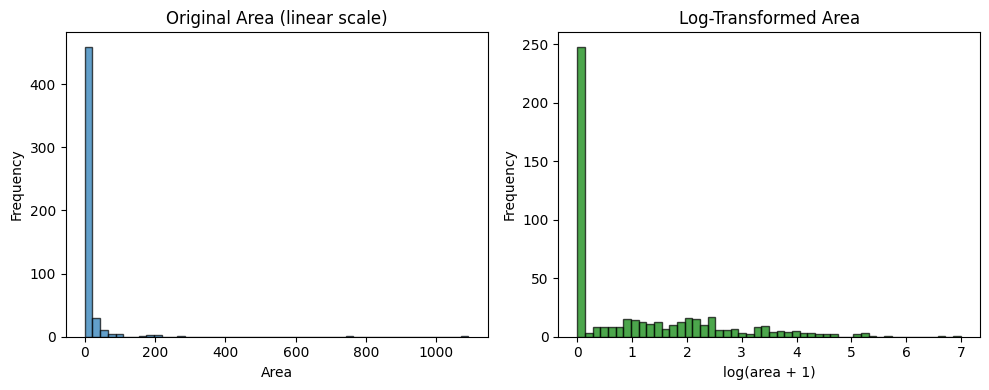

In [454]:
# Analizing a bit the column 'area' because my first models produced negative R²
# Histogram of original area 
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(fires_dt['area'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Area')
plt.ylabel('Frequency')
plt.title('Original Area (linear scale)')

plt.subplot(1, 2, 2)
plt.hist(np.log1p(fires_dt['area']), bins=50, edgecolor='black', alpha=0.7, color='green')
plt.xlabel('log(area + 1)')
plt.ylabel('Frequency')
plt.title('Log-Transformed Area')

plt.tight_layout()
plt.show()


In [455]:

print("Original area distribution")
print(Y_origin.describe())
print("\nLog-transformed distribution")
print(Y.describe()) #Handles skew, reduces outlier influence



Original area distribution
              area
count   517.000000
mean     12.847292
std      63.655818
min       0.000000
25%       0.000000
50%       0.520000
75%       6.570000
max    1090.840000

Log-transformed distribution
         area_log
count  517.000000
mean     1.111026
std      1.398436
min      0.000000
25%      0.000000
50%      0.418710
75%      2.024193
max      6.995620


# Preprocessing

Create two [Column Transformers](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html), called preproc1 and preproc2, with the following guidelines:

- Numerical variables

    * (Preproc 1 and 2) Scaling: use a scaling method of your choice (Standard, Robust, Min-Max). 
    * Preproc 2 only: 
        
        + Choose a transformation for any of your input variables (or several of them). Evaluate if this transformation is convenient.
        + The choice of scaler is up to you.

- Categorical variables: 
    
    * (Preproc 1 and 2) Apply [one-hot encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) where appropriate.


+ The only difference between preproc1 and preproc2 is the non-linear transformation of the numerical variables.
    


### Preproc 1

Create preproc1 below.

+ Numeric: scaled variables, no other transforms.
+ Categorical: one-hot encoding.

In [456]:
fires_dt.head()

,coord_x,coord_y,month,day,ffmc,dmc,dc,isi,temp,rh,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


In [457]:
num_cols = X.select_dtypes(include = ['int64', 'float64']).columns.tolist()
print("Continuous Numerical features:", num_cols)

cat_cols = X.select_dtypes(include = 'object').columns.tolist()
print("Categorical features:",cat_cols)


Continuous Numerical features: ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain']
Categorical features: ['month', 'day']


In [458]:
#Review variables to use PowerTransformer
skewness_df = pd.DataFrame({
    'Feature': num_cols,
    'Skewness': [fires_dt[col].skew() for col in num_cols],
})

# To add skewness interpretation
def skew_interpretation(skew):
    if abs(skew) > 1:
        return 'Skewed'
    else:
        return 'No Skewed'

skewness_df['Interpretation'] = skewness_df['Skewness'].apply(skew_interpretation)
skewness_df = skewness_df.sort_values('Skewness', ascending=False)

# Print the table
print(skewness_df.to_string(index=False))
print("\n")

Feature  Skewness Interpretation
   rain 19.816344         Skewed
    isi  2.536325         Skewed
     rh  0.862904      No Skewed
   wind  0.571001      No Skewed
    dmc  0.547498      No Skewed
coord_y  0.417296      No Skewed
coord_x  0.036246      No Skewed
   temp -0.331172      No Skewed
     dc -1.100445         Skewed
   ffmc -6.575606         Skewed




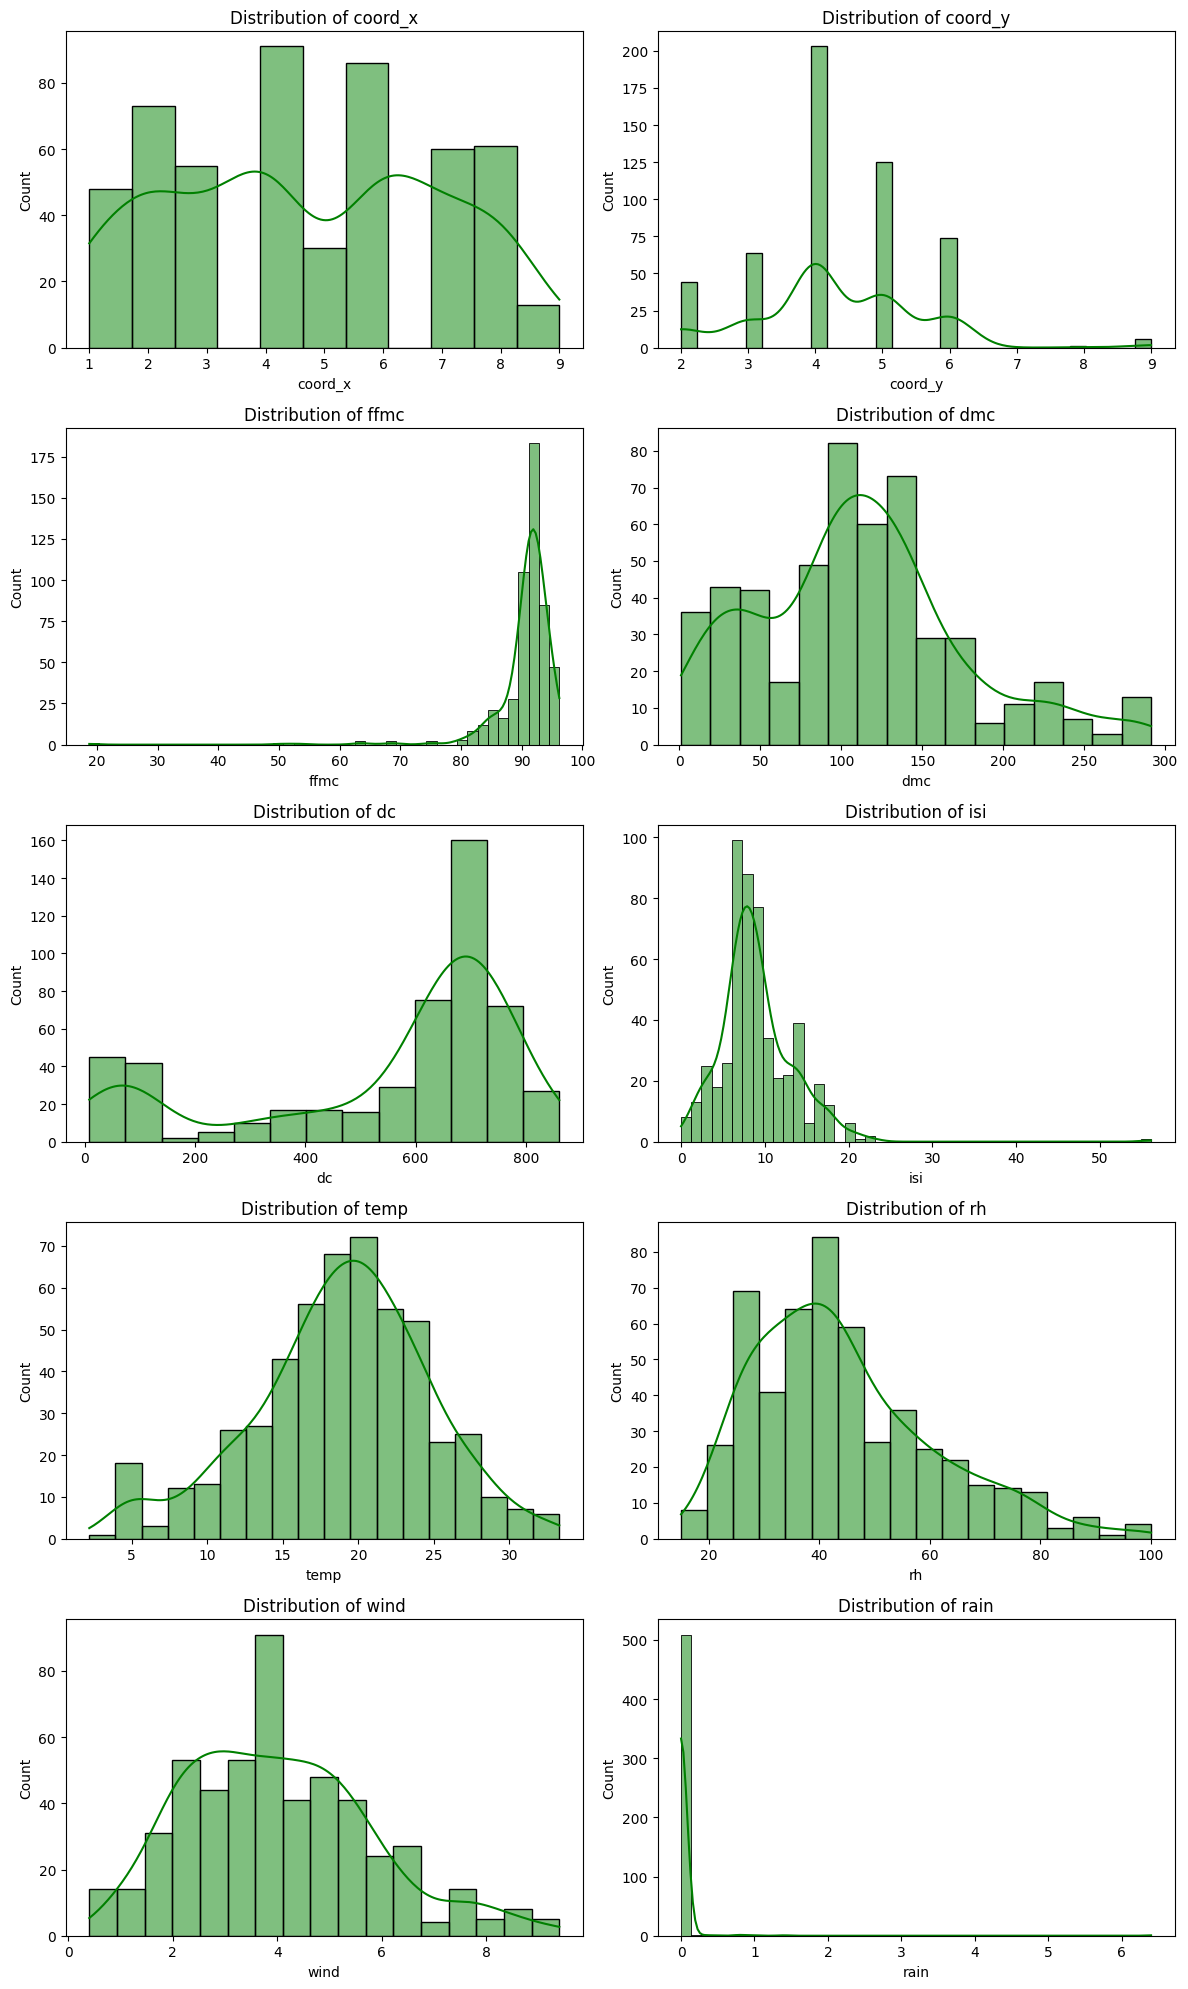

In [459]:
# Check distributions before transformation - to get confirmation since 
fig, axes = plt.subplots(5, 2, figsize=(12, 20))

for i, col in enumerate(num_cols):
    row, col_idx = i // 2, i % 2
    sns.histplot(fires_dt[col], kde=True, color='green', edgecolor='black', ax=axes[row, col_idx])
    axes[row, col_idx].set_title(f'Distribution of {col}')
 

plt.tight_layout()
plt.show()

In [460]:
# Preproc 1
# Standard for numerics + OneHotEncoder for categoricals
preproc_1 = ColumnTransformer(
    transformers=[
        ('num_transform', StandardScaler(), num_cols ),
        ('cat_transform', OneHotEncoder (
          handle_unknown='infrequent_if_exist', drop='if_binary',    min_frequency=2), cat_cols), # Group rare categories (<2)
    ], remainder='drop'
)


### Preproc 2

Create preproc1 below.

+ Numeric: scaled variables, non-linear transformation to one or more variables.
+ Categorical: one-hot encoding.

In [461]:
skewed_cols = skewness_df[skewness_df['Interpretation'] == 'Skewed']['Feature'].tolist()
skewed_cols
print("Skewed features:",skewed_cols)
num_cols2= [col for col in num_cols if col not in skewed_cols]
num_cols2
print("No Skewed features:",num_cols2)


Skewed features: ['rain', 'isi', 'dc', 'ffmc']
No Skewed features: ['coord_x', 'coord_y', 'dmc', 'temp', 'rh', 'wind']


In [462]:
skew_pipe = Pipeline([('transform', PowerTransformer(method='yeo-johnson')),
                   ('standardizer', RobustScaler())])


preproc_2 = ColumnTransformer(
    transformers=[
        ('sk_num_transform', skew_pipe, skewed_cols), 
        ('num_transform', RobustScaler(), num_cols2), 
        ('cat_transform', OneHotEncoder(
            handle_unknown='infrequent_if_exist', drop='if_binary',    min_frequency=2
        ), cat_cols),
    ], 
    remainder='drop'
)


## Model Pipeline


Create a [model pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html): 

+ Add a step labelled `preprocessing` and assign the Column Transformer from the previous section.
+ Add a step labelled `regressor` and assign a regression model to it. 

## Regressor

+ Use a regression model to perform a prediction. 

    - Choose a baseline regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Choose a more advance regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Both model choices are up to you, feel free to experiment.

In [390]:
# Split the data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)


In [366]:
pipeline_A  = Pipeline([
    ('preprocessing', preproc_1),
    ('regressor', Ridge(alpha=0.1, random_state=42))
])


In [364]:
pipeline_B = Pipeline([
    ('preprocessing', preproc_2),
    ('regressor', Ridge(alpha=0.1, random_state=42))
])

In [385]:
pipeline_C = Pipeline([
    ('preprocessing', preproc_1),
    ('regressor', RandomForestRegressor( random_state=42 )) 
])


In [386]:
pipeline_D = Pipeline([
    ('preprocessing', preproc_2),
    ('regressor', RandomForestRegressor( random_state=42 )) 
])

In [463]:
def evaluate_pipelines(pipe_dict, X_train, Y_train, cv=5):
    scoring = ['r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_error']
    results_list = []
    
    for name, pipeline in pipe_dict.items():
    
         # Perform cross-validation
        cv_results = cross_validate(
            pipeline, 
            X_train, 
            Y_train, 
            cv= 5, 
            scoring=scoring,
            return_train_score=True,
            return_estimator=True
        )
        
        # Calculate mean and std for each metric
        results = {
            'Pipeline': name,
            'Mean R2': cv_results['test_r2'].mean(),
            'Std R2': cv_results['test_r2'].std(),
            'Mean RMSE': (-cv_results['test_neg_root_mean_squared_error']).mean(),
            'Std RMSE': cv_results['test_neg_root_mean_squared_error'].std(),
            'Mean MAE': (-cv_results['test_neg_mean_absolute_error']).mean(),
            'Std MAE': cv_results['test_neg_mean_absolute_error'].std(),

        }
        
        results_list.append(results)

    
    return pd.DataFrame(results_list).round(4)


# pipeline dictionary
pipelines_to_evaluate = { 'pipeline_A': pipeline_A, 'pipeline_B': pipeline_B,'pipeline_C': pipeline_C, 'pipeline_D': pipeline_D}

# Evaluate all pipelines
results_cv = evaluate_pipelines(pipelines_to_evaluate, X_train, Y_train['area_log'] , cv=5)


print("\n")
print("SUMMARY OF CROSS-VALIDATION RESULTS")
print(results_cv.to_string(index=False))
print("\n")




SUMMARY OF CROSS-VALIDATION RESULTS
  Pipeline  Mean R2  Std R2  Mean RMSE  Std RMSE  Mean MAE  Std MAE
pipeline_A  -0.3738  0.6147     1.6015    0.3657    1.2124   0.1388
pipeline_B  -0.0520  0.0344     1.4270    0.1193    1.1632   0.0962
pipeline_C  -0.1675  0.0395     1.5049    0.1428    1.2251   0.1172
pipeline_D  -0.1725  0.0465     1.5079    0.1424    1.2271   0.1200




# Tune Hyperparams

+ Perform GridSearch on each of the four pipelines. 
+ Tune at least one hyperparameter per pipeline.
+ Experiment with at least four value combinations per pipeline.

In [464]:
# Pipeline with Tune
pipelines_dict = {
    'pipeline_A': (pipeline_A, {
        'regressor__alpha': [0.01, 0.1, 1.0, 10, 100, 300, 1000, 3000, 10000]
    }),
    'pipeline_B': (pipeline_B, {
        'regressor__alpha': [0.01, 0.1, 1.0, 10, 100, 300, 1000, 3000, 10000]
    }),
    'pipeline_C': (pipeline_C, {
        'regressor__n_estimators': [50, 100, 200],
        'regressor__max_depth': [None, 10, 20, 30],
        'regressor__min_samples_split': [2, 5, 10], 
        'regressor__min_samples_leaf': [1, 2, 4]   
    }),
    'pipeline_D': (pipeline_D, {
        'regressor__n_estimators': [50, 100, 200],
        'regressor__max_depth': [None, 10, 20, 30],
        'regressor__min_samples_split': [2, 5, 10], 
         'regressor__min_samples_leaf': [1, 2, 4]
    })
}

In [428]:
def get_pipeline_results(pipe_dict, X_train, Y_train, cv=5):

    scoring = ['r2', 'explained_variance', 'neg_root_mean_squared_error', 'neg_mean_absolute_error']
    results_list = []
    
    for name, (pipeline, param_grid) in pipe_dict.items():
        print(f"\n{name}\n") #get the name to split the tables 

        grid = GridSearchCV(pipeline, param_grid, scoring=scoring, cv=cv, refit='r2')
        grid.fit(X_train, Y_train)
        
        # Get cv_results_ as DataFrame
        res = pd.DataFrame(grid.cv_results_)

         # Create summary table
        param_cols = [f'param_{k}' for k in param_grid.keys()]
        
        table = res[param_cols + ['mean_test_r2', 'mean_test_neg_root_mean_squared_error', 
                                   'mean_test_neg_mean_absolute_error']].copy()
        table.columns = [c.replace('param_', '').replace('mean_test_', '') for c in table.columns]
        table['neg_root_mean_squared_error'] = -table['neg_root_mean_squared_error']
        table['neg_mean_absolute_error'] = -table['neg_mean_absolute_error']
        table = table.rename(columns={'neg_root_mean_squared_error': 'RMSE', 'neg_mean_absolute_error': 'MAE'})
        
        print(table.sort_values('r2', ascending=False).to_string(index=False))
    
        results_list.append({'Pipeline': name, 'Best Params': grid.best_params_, 
                            'Best R2': grid.best_score_, 'Best Estimator': grid.best_estimator_})
    
    return pd.DataFrame(results_list).round(4)

results_df = get_pipeline_results(pipelines_dict, X_train, Y_train['area_log'], cv=5)




pipeline_A

 regressor__alpha        r2     RMSE      MAE
         10000.00 -0.007115 1.395786 1.161457
          3000.00 -0.008583 1.396899 1.162084
          1000.00 -0.017497 1.403213 1.163867
           300.00 -0.059320 1.430857 1.169399
           100.00 -0.137745 1.477539 1.179277
            10.00 -0.278028 1.551836 1.199035
             1.00 -0.343206 1.584473 1.205600
             0.10 -0.373760 1.601457 1.212448
             0.01 -0.379196 1.604643 1.213955

pipeline_B

 regressor__alpha        r2     RMSE      MAE
           300.00 -0.003092 1.393356 1.155165
          1000.00 -0.003756 1.393614 1.158364
          3000.00 -0.005329 1.394587 1.160055
         10000.00 -0.006364 1.395248 1.160842
           100.00 -0.006769 1.396067 1.153439
            10.00 -0.027829 1.410680 1.161876
             1.00 -0.040017 1.418869 1.158899
             0.10 -0.051977 1.426984 1.163232
             0.01 -0.054711 1.428853 1.164445

pipeline_C

 regressor__n_estimators regressor__max_d

# Evaluate

+ Which model has the best performance?

In [465]:
# Find best pipeline by cross-validation 
best_pipeline = results_cv.loc[results_cv['Mean R2'].idxmax()]
print(f"Best pipeline by cross-validation : {best_pipeline['Pipeline']}")
print(f"Best R2 Score: {best_pipeline['Mean R2']:.4f} (+/- {best_pipeline['Std R2']*2:.4f})")
print(f"Best RMSE: {best_pipeline['Mean RMSE']:.4f}")

print("\n")
# Access the best-performing pipeline and its parameters.
for idx, row in results_df.iterrows():
    print(f"\n{row['Pipeline'].upper()}")
    print(f"  Best R²:     {row['Best R2']:.4f}")
    print(f"  Best Params: {row['Best Params']}")


Best pipeline by cross-validation : pipeline_B
Best R2 Score: -0.0520 (+/- 0.0688)
Best RMSE: 1.4270



PIPELINE_A
  Best R²:     -0.0071
  Best Params: {'regressor__alpha': 10000}

PIPELINE_B
  Best R²:     -0.0031
  Best Params: {'regressor__alpha': 300}

PIPELINE_C
  Best R²:     -0.0721
  Best Params: {'regressor__max_depth': 10, 'regressor__min_samples_leaf': 4, 'regressor__min_samples_split': 10, 'regressor__n_estimators': 100}

PIPELINE_D
  Best R²:     -0.0734
  Best Params: {'regressor__max_depth': 10, 'regressor__min_samples_leaf': 4, 'regressor__min_samples_split': 10, 'regressor__n_estimators': 100}


Pipeline_B with Ridge regression (alpha=300) performed best among all models, achieving the highest R2 (-0.0068) and lowest RMSE (1.393356). However, its R2  is still negative, meaning it predicts worse than simply using the average fire size.

Random Forest underperformed, likely due to the noisy data with many zeros and few large fires, which makes prediction difficult.
Given these results, it would be worth trying a classification model (predicting whether a fire occurs) or a weighted Random Forest to better handle the imbalanced data.


# Export

+ Save the best performing model to a pickle file.

In [466]:
#function to save all the models
def save_best_models(results_df, model_dir="./models"):
    os.makedirs(model_dir, exist_ok=True)
    
    for _, row in results_df.iterrows():
        name = row['Pipeline']
        estimator = row['Best Estimator']
        
        with open(f'{model_dir}/{name}.pkl', 'wb') as f:
            pickle.dump(estimator, f)
        print(f"✓ Saved: {model_dir}/{name}.pkl")


# Save all the  models, and ✓ Saved: ./models/pipeline_B.pkl is the best performing model 
save_best_models(results_df)

✓ Saved: ./models/pipeline_A.pkl
✓ Saved: ./models/pipeline_B.pkl
✓ Saved: ./models/pipeline_C.pkl
✓ Saved: ./models/pipeline_D.pkl


# Explain

+ Use SHAP values to explain the following only for the best-performing model:

    - Select an observation in your test set and explain which are the most important features that explain that observation's specific prediction.

    - In general, across the complete training set, which features are the most and least important.

+ If you were to remove features from the model, which ones would you remove? Why? How would you test that these features are actually enhancing model performance?

In [ ]:
#test
pipeline_B.fit(X_train, Y_train['area_log']) 
preproc_B = pipeline_B.named_steps['preprocessing']
ridge_B = pipeline_B.named_steps['regressor']
data_transform_test = preproc_B.transform(X_test)
feature_names = preproc_B.get_feature_names_out()

explainer = shap.LinearExplainer(
    ridge_B, 
    data_transform_test,
    feature_names = feature_names)

shap_values = explainer(data_transform_test)


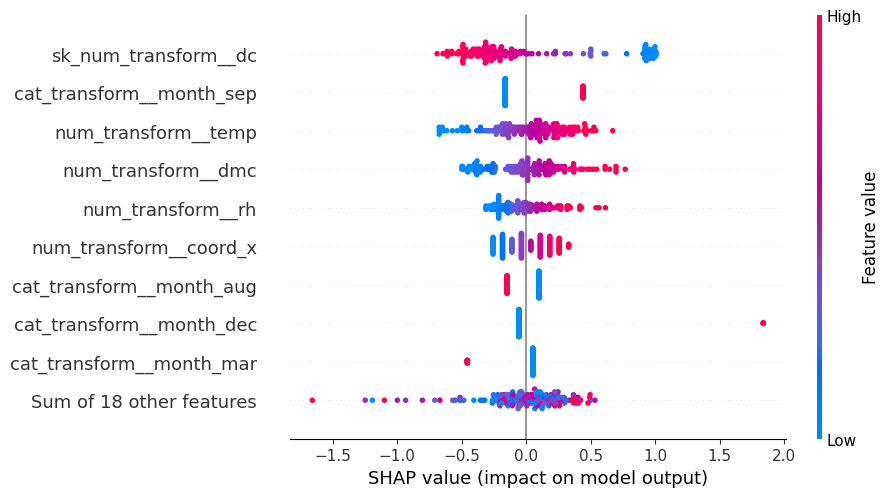

In [447]:
shap.plots.beeswarm(shap_values)

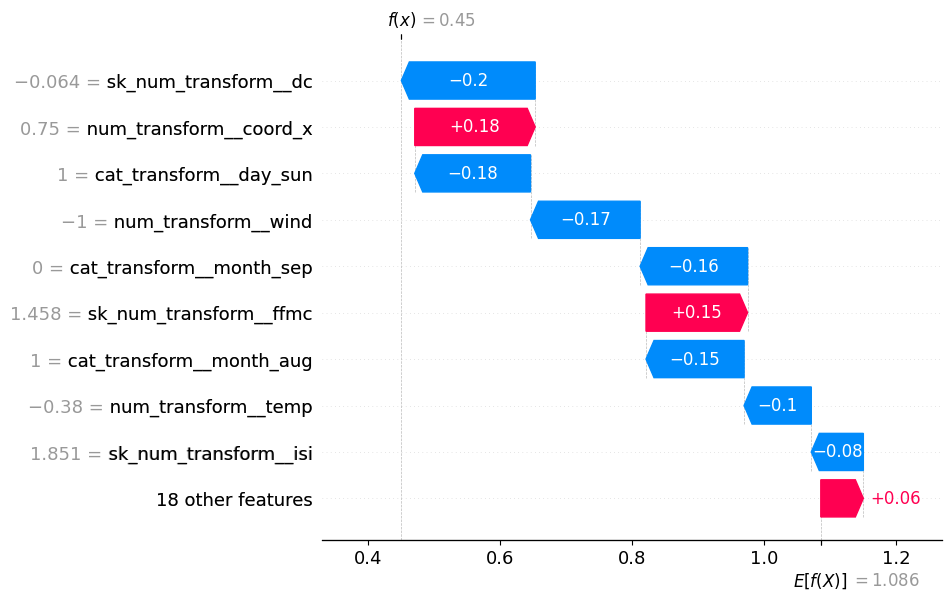

In [448]:
shap.plots.waterfall(shap_values[42])

In [ ]:
#training
data_transform_train = preproc_B.transform(X_train)

explainer = shap.LinearExplainer(
    ridge_B, 
    data_transform_train,
    feature_names = feature_names)

shap_values_train = explainer(data_transform_train)

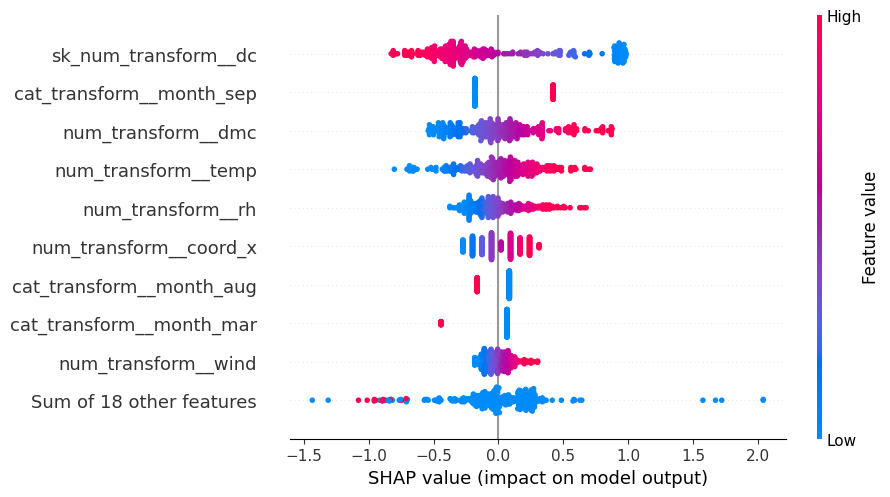

In [442]:
shap.plots.beeswarm(shap_values_train)

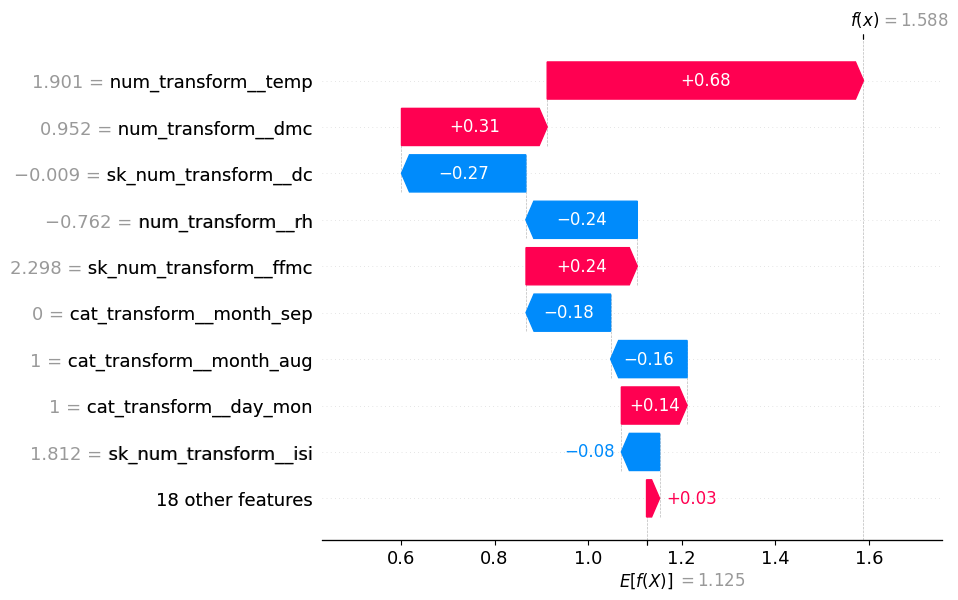

In [443]:
shap.plots.waterfall(shap_values_train[42])

For test sample 42, the model predicted a log‑transformed fire area of 0.45, which is below the average expected value of 1.086. The main features pushing this prediction down are Drought Code (DC) with a SHAP value of -0.203, Sunday (-0.175), wind (-0.166), September (-0.163), August (-0.149), and temperature (-0.102). Together, these factors lower the prediction. On the other hand, spatial coordinates (coord_x) (+0.182) and FFMC (+0.154) try to increase it, but they are not strong enough to overcome the negative effects. This suggests that the observation corresponds to a day with low fire risk, likely because of cooler weather, stronger winds, and drier conditions, even though some fuel moisture indicators are favorable.

Looking at the whole training set, the most influential features are DC (0.266),RH ( 0.238), September ( 0.181), August ( 0.163), ISI ( 0.082), temperature, and DMC (0.311). These features consistently show large SHAP values and are the main drivers of predictions. In contrast, day‑of‑week features (like Monday, Tuesday, Saturday, and Sunday) and some months such as October, April, and February have very low SHAP values (usually below 0.02), meaning they contribute almost nothing to the predictions.

Based on this, I would remove all day‑of‑week features and low-impact months like October and April, since their SHAP values are near zero and they do not help the model. To check if removing them actually improves performance, I would compare cross‑validated R² scores with and without these features using the same evaluation method. If the R² stays the same or gets better while the model becomes simpler, it would confirm that these features are not useful and can be safely dropped.


## Criteria

The [rubric](./assignment_2_rubric_clean.xlsx) contains the criteria for assessment.

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/production/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at the `help` channel. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.

# Reference

Cortez,Paulo and Morais,Anbal. (2008). Forest Fires. UCI Machine Learning Repository. https://doi.org/10.24432/C5D88D.